In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_partidos = pd.read_csv('../datos/partidos_cebollitas_fe82a1a4-e109-41b1-8b78-d9b4341dacaf.csv')
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

x = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y = df_partidos['diferencia_goles']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

modelo_rl = LinearRegression()
modelo_rl.fit(x_train, y_train)

y_pred = modelo_rl.predict(x_test)

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# calcular metricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE (Error cuadratico medio): {mse:.2f}')
print(f'RMSE (Raiz del error cuadratico medio): {rmse:.2f}')
print(f'MAE (Error absoluto Medio): {mae:.2f}')
print(f'R² (Coeficiente de determinacion): {r2:.2f}')

MSE (Error cuadratico medio): 4.96
RMSE (Raiz del error cuadratico medio): 2.23
MAE (Error absoluto Medio): 1.89
R² (Coeficiente de determinacion): -0.03


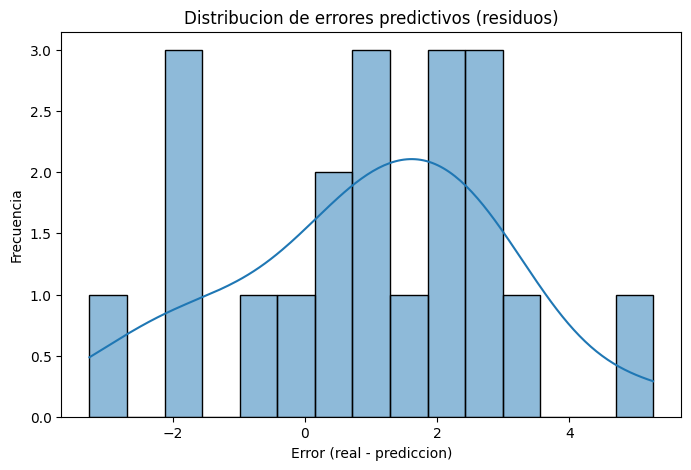

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, bins=15, kde=True)
plt.title('Distribucion de errores predictivos (residuos)')
plt.xlabel('Error (real - prediccion)')
plt.ylabel('Frecuencia')
plt.show()

In [10]:
import ipywidgets as widgets

def evaluar_predicciones(threshold_mae):
    calidad = 'buena' if mae <= threshold_mae else 'regular/mala'
    print(f'tu modelo tiene una MAE de {mae:.2f}, considerando {calidad}, (umbral definido: {threshold_mae}).')

umbral_widget = widgets.FloatSlider(min=0.1, max=5, step =0.1, description = 'UmbraL MAE')
widgets.interactive(evaluar_predicciones, threshold_mae = umbral_widget)

interactive(children=(FloatSlider(value=0.1, description='UmbraL MAE', max=5.0, min=0.1), Output()), _dom_clas…